# Handling Zman-seq Timestamps
CellDyc was applied to the GBM Monocyte Differentiation dataset (See details <span style="color: darkblue;">[here](datasets.rst#celldyc.datasets.core.mono2tam)</span>), where temporal information was derived from Zman-seq rather than traditional time-series sampling. Since Zman-seq provides continuous in vivo timestamping, the resulting temporal labeling is highly asynchronous.

## Import Packages

In [32]:
import scanpy as sc
import matplotlib.pyplot as plt
import celldyc as cdc

## Load the Data
The analysis is based on in-built  GBM Monocyte Differentiation dataset.

In [ ]:
# Load Zman-seq data
adata = cdc.datasets.mono2tam()
adata

AnnData object with n_obs × n_vars = 3108 × 4407
    obs: 'batch', 'mouse', 'time_assignment', 'cluster_colors', 'n_genes', 'Treatment', 'combined', 'Treatment_cluster'
    uns: 'cluster_colors_colors'
    obsm: 'X_mcg', 'X_pca'
    layers: 'spliced', 'unspliced'

This dataset contains cells from 4 time points and the temporal label is highly asynchronous.  

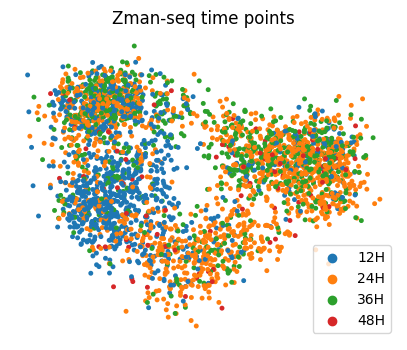

In [34]:
fig, ax = plt.subplots(figsize=(5,4))
ax = sc.pl.embedding(
    adata,
    color=["time_assignment"],  
    basis="mcg",              
    ax=ax,
    title="Zman-seq time points",                 
    legend_loc="lower right",  
    s=50, 
    frameon=False                   
)

## Preprocess the Data

In [35]:
adata = cdc.tl.preprocess(adata)

We transform descriptive time point strings into numerical format.

In [36]:
cat_map = {'12H': 12, '24H': 24, '36H': 36, '48H': 48}
adata.obs['numerical_time'] = adata.obs['time_assignment'].map(cat_map).astype('category')

## Estimation of Time Representation and Transcriptomic Velocity

We train CellDyc using the `recover_dyc` function. By default, predicted velocities are stored in **adata.layers['velocity']**, and predicted time values are stored in **adata.obs['getime']**.

In [37]:
cdc.tl.recover_dyc(adata, time_key="numerical_time", time_weight=0.001)

Training with early stop (max_epochs=500, patience=40)
epoch   1:loss=0.926128,trend_loss=0.925350,time_loss=0.778284
epoch  51:loss=0.623676,trend_loss=0.623134,time_loss=0.542161
epoch 101:loss=0.598081,trend_loss=0.597530,time_loss=0.551124
epoch 151:loss=0.577577,trend_loss=0.577017,time_loss=0.560104
Early stopping at epoch 191


AnnData object with n_obs × n_vars = 3108 × 2000
    obs: 'batch', 'mouse', 'time_assignment', 'cluster_colors', 'n_genes', 'Treatment', 'combined', 'Treatment_cluster', 'numerical_time', 'getime'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'getime_weights'
    uns: 'cluster_colors_colors', 'time_assignment_colors', 'log1p', 'hvg', 'pca', 'neighbors'
    obsm: 'X_mcg', 'X_pca'
    varm: 'PCs'
    layers: 'spliced', 'unspliced', 'velocity'
    obsp: 'distances', 'connectivities'

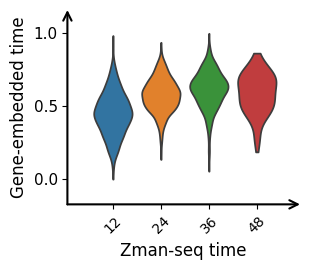

<Axes: xlabel='Zman-seq time', ylabel='Gene-embedded time'>

In [38]:
cdc.pl.getime_violin(adata,"getime","numerical_time",xlabel="Zman-seq time",remove_ticks=False)

We then project the velocities onto the metacell graph projection.

  0%|          | 0/3108 [00:00<?, ?cells/s]

computing velocity graph
finished.


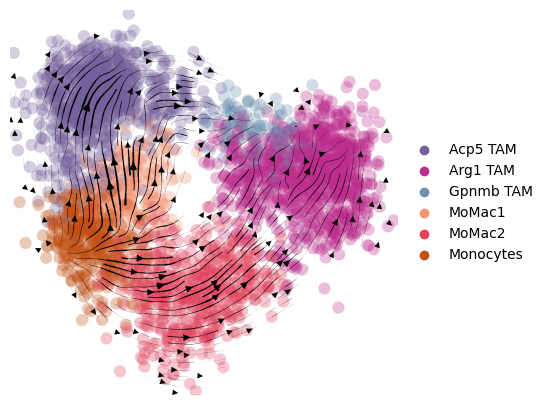

computing velocity embedding
finished.


In [40]:
cdc.pl.plot_velocity_projection(
    adata, 
    basis="mcg",            
    color='cluster_colors',                        
    legend_loc="right",  
    figsize=(5, 5)          
)